# 01 Matching moments and correlations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/01_matching_moments_and_correlations.ipynb)

**The question.** You have a history of returns for a few assets: one sample,
a few hundred observations, the only one there is. You need more data that
looks like it: to size a portfolio's risk, to test a rule, to answer "what if"
on more than the months that happened. What does "looks like it" mean, how do
you produce such data, and how do you check it?

**The answer in one paragraph.** State what the synthetic data must reproduce
(the *targets*: here the means, volatilities, skewness, kurtosis and
correlations of the history), *fit* a generator that reproduces them, *check*
the generator's output against the targets, then *use* it: draw as many
observations as you need, or paths over a horizon, and change one target to
see the consequence. This four-step process, targets, fit, check, use, is the
same in every notebook of this series; the objects change.

**What you need before this notebook.** Nothing.

**What this notebook adds.** The four steps on six ETFs with the simplest
generator, one that matches the four moments of each asset and every pairwise
correlation. It ends by finding what this generator misses, which the next
notebook fixes.

Runtime: under a minute.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import load_etf_monthly, Targets, FleishmanMarket, exceedance_curve
from scipy import stats

cvinemarketgen 0.3.0


## The history

Monthly total returns of six ETFs since January 2005: U.S. large and small
caps (SPY, IWM), developed markets outside the U.S. (EFA), long and
intermediate Treasuries (TLT, IEF) and gold (GLD), from adjusted closes,
$r_t = P_t / P_{t-1} - 1$, cached locally. Two hundred and sixty months. The
loader is the only network call of the notebook; use your own DataFrame of
returns in its place, one column per asset, one row per period.

In [2]:
X = load_etf_monthly(["SPY", "IWM", "EFA", "TLT", "IEF", "GLD"], start="2004-12", cache=os.path.join(ROOT, "data", "etf_cache_course.csv"))
print(X.shape[0], "months,", X.index.min(), "to", X.index.max())
X.tail()

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_course.csv: 261 months, 2005-01 to 2026-09
261 months, 2005-01 to 2026-09


,SPY,IWM,EFA,TLT,IEF,GLD
month,,,,,,
2026-05,0.052626,0.044825,0.024238,0.005334,-0.000190,-0.015437
2026-06,-0.010293,0.036961,0.006907,0.011659,0.002512,-0.116849
2026-07,0.000348,-0.030787,0.016365,-0.044738,-0.013887,0.008578
2026-08,0.026799,0.009375,0.017712,0.007324,0.001166,0.099263
2026-09,-0.004522,-0.030919,-0.023080,-0.011617,-0.017401,-0.017751


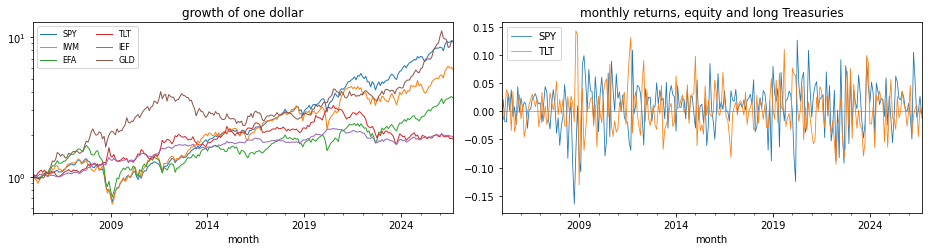

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
(1 + X).cumprod().plot(ax=axes[0], lw=1); axes[0].set_title("growth of one dollar"); axes[0].set_yscale("log"); axes[0].legend(fontsize=8, ncol=2)
X[["SPY", "TLT"]].plot(ax=axes[1], lw=0.8); axes[1].set_title("monthly returns, equity and long Treasuries"); axes[1].axhline(0, color="grey", lw=0.6)
plt.tight_layout(); plt.show()

## Step 1: targets

The targets are the numbers the synthetic data must reproduce. From a history
of $n$ observations $r_{i,1}, \dots, r_{i,n}$ of asset $i$, they are the
sample moments,

$$
\mu_i = \frac{1}{n} \sum_t r_{i,t}, \qquad
\sigma_i^2 = \frac{1}{n-1} \sum_t (r_{i,t} - \mu_i)^2, \qquad
\gamma_{1,i} = \frac{\frac{1}{n}\sum_t (r_{i,t} - \mu_i)^3}{\hat s_i^3}, \qquad
\gamma_{2,i} = \frac{\frac{1}{n}\sum_t (r_{i,t} - \mu_i)^4}{\hat s_i^4},
$$

with $\hat s_i$ the biased standard deviation (the pandas estimators, which
apply the usual small-sample corrections), and the Pearson correlation matrix
$\Sigma^*$ with entries $\Sigma^*_{ik} = \mathrm{Corr}(r_i, r_k)$. Four
numbers per asset and one per pair: for $N$ assets, $4N + N(N-1)/2$ targets,
33 here. The kurtosis is raw, so the normal has $\gamma_2 = 3$; a value above
3 means fatter tails than the normal, a negative skewness means the large
moves are falls.

`Targets.from_history` computes them and keeps the history for the checks
below. Read the table: equity has negative skewness and kurtosis above 4; the
Treasuries have positive skewness; gold is close to normal; the two Treasury
funds are correlated at 0.92 and nearly uncorrelated with equity.

In [4]:
t = Targets.from_history(X)
print(t)
display(t.moments.round(3)); t.corr.round(2)

Targets(6 assets: SPY, IWM, EFA, TLT, ...; layer=returns)


,mean,vol,skew,kurt
SPY,0.010,0.043,-0.552,4.244
IWM,0.008,0.057,-0.376,4.244
EFA,0.006,0.048,-0.548,4.787
TLT,0.003,0.039,0.435,4.398
IEF,0.003,0.019,0.197,3.810
GLD,0.010,0.050,-0.002,3.248


,SPY,IWM,EFA,TLT,IEF,GLD
SPY,1.00,0.89,0.86,-0.09,-0.07,0.09
IWM,0.89,1.00,0.77,-0.14,-0.13,0.04
EFA,0.86,0.77,1.00,-0.05,-0.01,0.22
TLT,-0.09,-0.14,-0.05,1.00,0.92,0.23
IEF,-0.07,-0.13,-0.01,0.92,1.00,0.31
GLD,0.09,0.04,0.22,0.23,0.31,1.00


## Step 2: fit a generator that matches the targets

The simplest generator with these targets is Fleishman's (1978). Each asset is
a cubic polynomial of a standard normal,

$$
X_i = a_i + b_i Z_i + c_i Z_i^2 + d_i Z_i^3, \qquad Z_i \sim N(0, 1),
$$

whose four coefficients are set so that $X_i$ has mean 0, variance 1 and the
target skewness and kurtosis; the moments of a polynomial of a normal are
polynomials of its coefficients, so this is a system of three equations in
$(b_i, c_i, d_i)$ with $a_i = -c_i$, solved numerically, and the mean and
volatility are applied afterwards, $r_i = \mu_i + \sigma_i X_i$. The system
has a solution when $\gamma_{2,i} - 3 \ge \gamma_{1,i}^2 - 2$, which every
return series in practice satisfies.

The dependence is put in the normals. If $(Z_i, Z_k)$ have correlation
$\rho_Z$, the cubics have correlation

$$
\mathrm{Corr}(X_i, X_k) = \rho_Z \,(b_i b_k + 3 b_i d_k + 3 d_i b_k + 9 d_i d_k) + \rho_Z^2\, (2 c_i c_k) + \rho_Z^3\, (6 d_i d_k),
$$

(Vale and Maurelli, 1983), so for each pair the *intermediate* correlation
$\rho_Z$ is the root of this cubic that makes $\mathrm{Corr}(X_i, X_k)$ equal
to the target $\Sigma^*_{ik}$. The matrix of intermediate correlations is
made positive definite if needed, and the normals are drawn jointly from it by
a Cholesky factor. `fit` does all of this; it is instantaneous. The
coefficients table is the fitted polynomial per asset; the intermediate
correlations are close to the targets because the polynomials are close to
linear here.

In [5]:
fm = FleishmanMarket(t).fit()
print(fm)
display(fm.coefficients.round(4))
print("intermediate correlations of the normals minus the target correlations (max abs):", round(float((fm.intermediate_corr - t.corr).abs().values.max()), 4))

FleishmanMarket(6 assets, fitted)


,a,b,c,d
SPY,0.0787,0.9082,-0.0787,0.0277
IWM,0.0519,0.8952,-0.0519,0.0329
EFA,0.0726,0.8673,-0.0726,0.0408
TLT,-0.0594,0.8872,0.0594,0.0352
IEF,-0.0284,0.9217,0.0284,0.0252
GLD,0.0003,0.9713,-0.0003,0.0095


intermediate correlations of the normals minus the target correlations (max abs): 0.0043


## Step 3: simulate and check

`simulate(n)` draws $n$ joint observations. The draw is then compared with the
targets: for each asset the four sample moments of the draw against the
targets, and for each pair the simulated correlation against $\Sigma^*_{ik}$.
The generator refits its coefficients on the draw and accepts it only when
every difference is within tolerance ($2 \times 10^{-4}$ on means and
volatilities, $5 \times 10^{-2}$ on skewness and kurtosis, $0.02$ on
correlations), redrawing otherwise; `diagnostics` prints the differences.
This check is the one to run every time a market is fitted: it says whether
the synthetic data is what it was asked to be.

In [6]:
S = fm.simulate(25000, seed=1)
print(S.shape)
d = fm.diagnostics(S)
d.summary(digits=4);

(25000, 6)
25000 simulated observations (returns layer)
     mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
SPY       0.0095          0.0095        0.0      0.0427         0.0427       0.0      -0.5525         -0.5525       -0.0       4.2440          4.2445     0.0005
IWM       0.0084          0.0084        0.0      0.0572         0.0572       0.0      -0.3763         -0.3763       -0.0       4.2437          4.2442     0.0005
EFA       0.0062          0.0062        0.0      0.0482         0.0482       0.0      -0.5484         -0.5484       -0.0       4.7873          4.7879     0.0006
TLT       0.0031          0.0031        0.0      0.0392         0.0392       0.0       0.4354          0.4354        0.0       4.3977          4.3983     0.0005
IEF       0.0027          0.0027        0.0      0.0187         0.0187       0.0       0.1972          0.1972        0.0       3.8098      

## What the synthetic data looks like

Two views. Left, the distribution of SPY's monthly return in the draw against
the normal with the same mean and volatility: the left tail is heavier and the
peak higher, which is what negative skewness and kurtosis above 3 mean. Right,
the joint draw of SPY and EFA, with the history's points on top: the cloud
has the history's correlation and its elongated shape. Everything the targets
asked for is there.

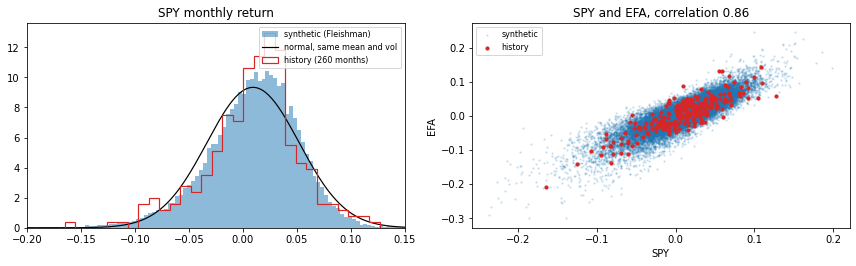

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
grid = np.linspace(S["SPY"].min(), S["SPY"].max(), 300)
axes[0].hist(S["SPY"], bins=120, density=True, alpha=0.5, label="synthetic (Fleishman)")
axes[0].plot(grid, stats.norm.pdf(grid, t.moments.loc["SPY", "mean"], t.moments.loc["SPY", "vol"]), color="black", lw=1.2, label="normal, same mean and vol")
axes[0].hist(X["SPY"], bins=30, density=True, histtype="step", color="tab:red", lw=1.2, label="history (260 months)")
axes[0].set_title("SPY monthly return"); axes[0].legend(fontsize=8); axes[0].set_xlim(-0.2, 0.15)
axes[1].scatter(S["SPY"], S["EFA"], s=2, alpha=0.15, label="synthetic"); axes[1].scatter(X["SPY"], X["EFA"], s=10, color="tab:red", label="history")
axes[1].set_xlabel("SPY"); axes[1].set_ylabel("EFA"); axes[1].set_title(f"SPY and EFA, correlation {t.corr.loc['SPY', 'EFA']:.2f}"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 4: use it

Steps 1 to 3 produced a dataset with the history's moments and correlations.
From here on that dataset replaces the history as the input to any
calculation: the risk of a portfolio, the performance of a rule, a stress. The
gain is size. The history has 260 months, so a 5 percent quantile computed on
it rests on 13 observations and moves if two months are added or dropped; the
synthetic data has 25,000, so the same quantile is a number.

The example is an equity portfolio diversified across markets: equal weights
in U.S. large caps, U.S. small caps and developed markets outside the U.S.
(SPY, IWM, EFA), the kind of diversification whose value is decided in bad
months. A portfolio is a fixed vector of weights $\mathbf w$; its return on
each observation is $r_p = \mathbf w' \mathbf r$, and its monthly 5 percent value
at risk and expected shortfall are

$$
\mathrm{VaR}_{5\%} = -q_{0.05}(r_p), \qquad \mathrm{ES}_{5\%} = -\mathbb E\big[r_p \mid r_p \le q_{0.05}(r_p)\big],
$$

minus the 5 percent quantile, and minus the mean of the returns below it. The
table gives both on the synthetic data, on the history, and under a normal
distribution with the portfolio's mean and volatility (for which
$q_{0.05} = \mu_p - 1.645\,\sigma_p$ and the shortfall has a closed form).

How to read the three. The normal gives the smallest tail: it ignores the
skewness and kurtosis of the assets. The synthetic data gives a larger one,
because its marginals carry them. The history gives the largest, above the
synthetic value, although the generator reproduced every target. The next
cell finds out why.

In [8]:
w = pd.Series({"SPY": 1 / 3, "IWM": 1 / 3, "EFA": 1 / 3}).reindex(X.columns).fillna(0.0)    # global equity, equal weights
def var_es(r, alpha=0.05):
    q = np.quantile(r, alpha); return -q, -r[r <= q].mean()
rp_sim, rp_hist = S @ w, X @ w
mu_p, sd_p = rp_hist.mean(), rp_hist.std()
rows = {"synthetic (Fleishman, 25,000 obs.)": var_es(rp_sim.values), "history (260 months)": var_es(rp_hist.values),
        "normal, same mean and vol": (-(mu_p + sd_p * stats.norm.ppf(0.05)), -(mu_p - sd_p * stats.norm.pdf(stats.norm.ppf(0.05)) / 0.05))}
pd.DataFrame(rows, index=["VaR 5% (monthly, %)", "ES 5% (monthly, %)"]).T.mul(100).round(2)

,"VaR 5% (monthly, %)","ES 5% (monthly, %)"
"synthetic (Fleishman, 25,000 obs.)",7.31,10.20
history (260 months),8.22,10.39
"normal, same mean and vol",6.86,8.80


### Why the synthetic tail is short

The Cornish-Fisher expansion says that the quantile of a distribution is, to
a good approximation, a function of its first four moments: with
$z = \Phi^{-1}(\alpha)$, skewness $\gamma_1$ and excess kurtosis $\kappa = \gamma_2 - 3$,

$$
q_\alpha \approx \mu + \sigma \left[ z + \frac{z^2 - 1}{6}\gamma_1 + \frac{z^3 - 3z}{24}\kappa - \frac{2z^3 - 5z}{36}\gamma_1^2 \right].
$$

So if the portfolio's four moments were matched, its VaR would be. The first
table gives the portfolio's four moments on the history and on the synthetic
data, its empirical VaR and its Cornish-Fisher VaR. The mean and volatility
agree; the skewness and kurtosis do not ($-0.62$ and $4.7$ against $-0.44$
and $4.2$). Cornish-Fisher separates the gap in two. On the synthetic data it
reproduces the empirical VaR (7.30 against 7.31: 25,000 observations). On the
history it gives 7.47 against the empirical 8.22: the portfolio's moments
account for a VaR about 0.2 above the synthetic one, and the remaining 0.75 is
the sampling noise of a quantile estimated on 13 months. The expected
shortfall, which averages those 13 months instead of picking one, agrees to
0.2 as well. So the true gap is the small one, and it sits in the portfolio's
third and fourth moments.

Why are they not matched, when each asset's four moments are? Because a
portfolio's skewness and kurtosis depend on how the assets move *together in
the tails*, which no target described: each asset's moments describe it
alone, and a correlation is one number for a pair, an average over the whole
distribution. The second table asks the sharper question: how correlated are
two equity markets when one of them falls? For a pair $(x, y)$ with $x$
standardized and a threshold $z$ in standard deviations, the exceedance
correlation is

$$
\hat\rho(z) = \begin{cases} \mathrm{Corr}(x, y \mid x < z) & z < 0, \\ \mathrm{Corr}(x, y \mid x \ge z) & z \ge 0, \end{cases}
$$

the Pearson correlation on the observations where $x$ is below $z$ (its bad
months) or above $z$ (its good months). The table gives it at $z = -1, 0, 1$
for SPY against EFA and IWM. In the history the correlation of SPY with EFA
is 0.81 in SPY's bad months and 0.34 in its good ones: diversification across
markets works when it is not needed and fails when it is. In the synthetic
data the profile is flat around the target correlation, 0.62 on both sides.
The generator has the right correlation on average and the wrong one in the
tail, and an equal-weight equity portfolio inherits the difference as missing
skewness and kurtosis. Each asset's own tail, in the last two columns, is
reproduced; the joint tail is not.

This is the discipline of the whole series: a number computed on synthetic
data is only as good as the targets, and what was not targeted is not
reproduced. Before turning to the remedy, the same question for a portfolio
that holds bonds.

In [9]:
def cf_var(r, alpha=0.05):
    m, s, g1, k = r.mean(), r.std(), stats.skew(r), stats.kurtosis(r)                       # k: excess kurtosis
    z = stats.norm.ppf(alpha); zc = z + (z**2 - 1) * g1 / 6 + (z**3 - 3 * z) * k / 24 - (2 * z**3 - 5 * z) * g1**2 / 36
    return -(m + s * zc)
rows = {}
for name, r in [("history", rp_hist.values), ("synthetic (Fleishman)", rp_sim.values)]:
    rows[name] = {"mean (%)": r.mean() * 100, "vol (%)": r.std() * 100, "skewness": stats.skew(r), "kurtosis": stats.kurtosis(r) + 3,
                  "VaR 5%, empirical (%)": var_es(r)[0] * 100, "VaR 5%, Cornish-Fisher (%)": cf_var(r) * 100}
print("the global equity portfolio: four moments and VaR"); display(pd.DataFrame(rows).T.round(2))
rows = {}
for name, D in [("history", X), ("synthetic (Fleishman)", S)]:
    e = exceedance_curve(D["SPY"], D["EFA"], [-1.0, 0.0, 1.0]); i = exceedance_curve(D["SPY"], D["IWM"], [-1.0, 0.0, 1.0])
    rows[name] = {"corr(SPY, EFA | SPY < -1 sd)": e.iloc[0], "corr(SPY, EFA | SPY >= 0)": e.iloc[1], "corr(SPY, EFA | SPY >= +1 sd)": e.iloc[2],
                  "corr(SPY, IWM | SPY < -1 sd)": i.iloc[0], "corr(SPY, IWM | SPY >= +1 sd)": i.iloc[2],
                  "SPY VaR 5% (%)": var_es(D["SPY"].values)[0] * 100, "EFA VaR 5% (%)": var_es(D["EFA"].values)[0] * 100}
print("the joint tail: exceedance correlations of SPY with EFA and IWM, and each asset's own tail"); pd.DataFrame(rows).T.round(2)

the global equity portfolio: four moments and VaR


,mean (%),vol (%),skewness,kurtosis,"VaR 5%, empirical (%)","VaR 5%, Cornish-Fisher (%)"
history,0.8,4.65,-0.62,4.66,8.22,7.47
synthetic (Fleishman),0.8,4.65,-0.44,4.21,7.31,7.30


the joint tail: exceedance correlations of SPY with EFA and IWM, and each asset's own tail


,"corr(SPY, EFA | SPY < -1 sd)","corr(SPY, EFA | SPY >= 0)","corr(SPY, EFA | SPY >= +1 sd)","corr(SPY, IWM | SPY < -1 sd)","corr(SPY, IWM | SPY >= +1 sd)",SPY VaR 5% (%),EFA VaR 5% (%)
history,0.81,0.62,0.34,0.86,0.81,6.94,7.85
synthetic (Fleishman),0.62,0.73,0.62,0.67,0.68,6.52,7.74


### A second portfolio: equity and bonds

Most portfolios are not equity only. A 60/40 portfolio, 60 percent SPY and 40
percent TLT, relies on Treasuries to offset equity's bad months; in the sample
the two are almost uncorrelated ($-0.09$). The first table gives its VaR and
ES on the synthetic data, the history and the normal, then its four moments:
again the mean and volatility agree and the skewness and kurtosis do not
($-0.68$ and $5.0$ against $-0.31$ and $3.8$), so the same gap in the tail.

But the cause is different, and the second table shows it. The exceedance
correlation of SPY with TLT is near zero on both sides in the history (0.05 in
SPY's bad months, $-0.03$ in its good ones) and in the synthetic data: there is
no asymmetry to reproduce. What the history has and the synthetic data has
not is in the last column, the *co-kurtosis*

$$
\mathbb E[s^2 b^2], \qquad s = \frac{r_{SPY} - \mu_{SPY}}{\sigma_{SPY}},\ \ b = \frac{r_{TLT} - \mu_{TLT}}{\sigma_{TLT}},
$$

the average product of the squared standardized returns, which equals
$1 + 2\rho^2$ when the sizes of the two moves are independent (1.02 here at
$\rho = -0.09$). In the history it is 1.75: large months of equity and large
months of Treasuries coincide, in either direction (2008, 2020, 2022), so the
portfolio's variance is not the same every month, and its tail is fatter than
its correlation says. The synthetic data has the Gaussian value; each asset's
own tail is again reproduced.

Two portfolios, two different properties of the joint tail that moments and
correlations do not describe: for equity markets, a dependence that is stronger
in bad months than in good ones; for equity and bonds, large moves that
coincide with no direction. Notebook 02 makes both a target.

In [10]:
w2 = pd.Series({"SPY": 0.6, "TLT": 0.4}).reindex(X.columns).fillna(0.0)
rp2_sim, rp2_hist = (S @ w2).values, (X @ w2).values
mu2, sd2 = rp2_hist.mean(), rp2_hist.std()
rows = {"synthetic (Fleishman)": var_es(rp2_sim) + (stats.skew(rp2_sim), stats.kurtosis(rp2_sim) + 3),
        "history (260 months)": var_es(rp2_hist) + (stats.skew(rp2_hist), stats.kurtosis(rp2_hist) + 3),
        "normal, same mean and vol": (-(mu2 + sd2 * stats.norm.ppf(0.05)), -(mu2 - sd2 * stats.norm.pdf(stats.norm.ppf(0.05)) / 0.05), 0.0, 3.0)}
tab = pd.DataFrame(rows, index=["VaR 5% (%)", "ES 5% (%)", "skewness", "kurtosis"]).T
tab[["VaR 5% (%)", "ES 5% (%)"]] *= 100
print("the 60/40 portfolio (SPY, TLT)"); display(tab.round(2))
z_ = lambda v: (v - v.mean()) / v.std()                     # standardize
rows = {}
for name, D in [("history", X), ("synthetic (Fleishman)", S)]:
    e = exceedance_curve(D["SPY"], D["TLT"], [-1.0, 0.0, 1.0]); s_, b_ = z_(D["SPY"]), z_(D["TLT"]); rho = np.corrcoef(s_, b_)[0, 1]
    rows[name] = {"corr(SPY, TLT | SPY < -1 sd)": e.iloc[0], "corr(SPY, TLT | SPY >= 0)": e.iloc[1], "corr(SPY, TLT | SPY >= +1 sd)": e.iloc[2],
                  "TLT VaR 5% (%)": var_es(D["TLT"].values)[0] * 100, "1 + 2 rho^2": 1 + 2 * rho**2, "co-kurtosis E[s^2 b^2]": np.mean(s_**2 * b_**2)}
print("SPY and TLT: exceedance correlations, TLT's own tail, and the co-kurtosis against its value under independent sizes"); pd.DataFrame(rows).T.round(2)

the 60/40 portfolio (SPY, TLT)


,VaR 5% (%),ES 5% (%),skewness,kurtosis
synthetic (Fleishman),4.22,5.92,-0.31,3.80
history (260 months),4.51,6.53,-0.68,5.02
"normal, same mean and vol",4.04,5.25,0.00,3.00


SPY and TLT: exceedance correlations, TLT's own tail, and the co-kurtosis against its value under independent sizes


,"corr(SPY, TLT | SPY < -1 sd)","corr(SPY, TLT | SPY >= 0)","corr(SPY, TLT | SPY >= +1 sd)",TLT VaR 5% (%),1 + 2 rho^2,co-kurtosis E[s^2 b^2]
history,0.05,-0.07,-0.03,5.46,1.01,1.75
synthetic (Fleishman),-0.01,-0.05,-0.04,5.60,1.01,1.02


### First view: the correlations between equity markets

The targets are inputs, not just statistics. A view is a change of one of them
with everything else kept. The first view is on diversification: the
correlations between the three equity markets are 0.77 to 0.89 in the sample;
the view sets all three to 0.50, the level of the 1990s, and keeps every other
target: the same means, volatilities, skewness and kurtosis, the same
correlations with bonds and gold. (A correlation matrix must stay positive
definite; this one does.)

What should happen to the portfolio? Nothing to any single asset, by
construction; only to the way they add up. For $N$ assets with weights
$w_i$, the portfolio variance is

$$
\sigma_p^2 = \sum_i w_i^2 \sigma_i^2 + \sum_{i \ne k} w_i w_k\, \rho_{ik}\, \sigma_i \sigma_k ,
$$

so lowering the three $\rho_{ik}$ from about 0.84 to 0.50 removes a third of
the second sum: the monthly volatility falls from 4.7 to 4.0 percent, 13
percent less risk for the same assets. Every column of the table is computed
on the simulated data under each set of targets except the implied portfolio
volatility, which is the check: the assets' own volatilities are unchanged,
the portfolio's equals the implied value, and the VaR and ES fall with it.

In [11]:
t1 = Targets.from_history(X)
for a, b in [("SPY", "IWM"), ("SPY", "EFA"), ("IWM", "EFA")]:
    t1.corr.loc[a, b] = t1.corr.loc[b, a] = 0.50            # view: correlations between equity markets back to 0.5
print("smallest eigenvalue of the new correlation matrix:", round(float(np.linalg.eigvalsh(t1.corr.values).min()), 3))
S1 = FleishmanMarket(t1).fit().simulate(25000, seed=1)
def port_vol(tg):                                        # portfolio volatility implied by the targets: sqrt(w' Sigma w)
    Sigma = np.outer(tg.vol, tg.vol) * tg.corr.values
    return float(np.sqrt(w.values @ Sigma @ w.values))
rows = {}
for name, tg, SS in [("sample targets", t, S), ("view: equity correlations 0.50", t1, S1)]:
    rp = (SS @ w).values; v, e = var_es(rp)
    rows[name] = {"corr(SPY, EFA) target": tg.corr.loc["SPY", "EFA"], "SPY vol, simulated (%)": SS["SPY"].std() * 100, "EFA vol, simulated (%)": SS["EFA"].std() * 100,
                  "portfolio vol, implied by targets (%)": port_vol(tg) * 100, "portfolio vol, simulated (%)": rp.std() * 100, "VaR 5%, simulated (%)": v * 100, "ES 5%, simulated (%)": e * 100}
pd.DataFrame(rows).T.round(2)

smallest eigenvalue of the new correlation matrix: 0.079


,"corr(SPY, EFA) target","SPY vol, simulated (%)","EFA vol, simulated (%)","portfolio vol, implied by targets (%)","portfolio vol, simulated (%)","VaR 5%, simulated (%)","ES 5%, simulated (%)"
sample targets,0.86,4.27,4.82,4.66,4.65,7.31,10.20
view: equity correlations 0.50,0.50,4.27,4.82,4.04,4.03,6.15,8.54


### Second view: the volatility of one asset

The second view is on one market's volatility: SPY's volatility target
(`t.vol`) is set to 6 percent a month, 21 percent a year, instead of the
sample's 4.3 percent (15 percent a year), a rise of 40 percent. Refit and
redraw; the other 32 targets are unchanged.

What should happen to the portfolio? In the variance formula of the first
view, $\sigma_{SPY}$ enters its own term and its two cross terms, with a
weight of one third, so the portfolio volatility rises from 4.7 to 5.2 percent
a month, about 12 percent, less than SPY's 40 because the other two markets'
volatilities do not move. The table is computed on the simulated data under
both sets of targets, as in the first view, with the implied portfolio
volatility as the check and a ratio row: SPY's volatility, the portfolio's,
its VaR and ES all rise, the tail a little more than the volatility because
the mean, unchanged, is subtracted from it.

In [12]:
t2 = Targets.from_history(X)
t2.vol["SPY"] = 0.06                                     # view: SPY volatility 6 percent a month (21 percent a year) instead of the sample's 4.3 (15)
S2 = FleishmanMarket(t2).fit().simulate(25000, seed=1)
rows = {}
for name, tg, SS in [("sample targets", t, S), ("view: SPY vol 6% a month", t2, S2)]:
    rp = (SS @ w).values; v, e = var_es(rp)
    rows[name] = {"SPY vol target (%)": tg.vol["SPY"] * 100, "SPY vol, simulated (%)": SS["SPY"].std() * 100, "portfolio vol, implied by targets (%)": port_vol(tg) * 100,
                  "portfolio vol, simulated (%)": rp.std() * 100, "VaR 5%, simulated (%)": v * 100, "ES 5%, simulated (%)": e * 100}
tab = pd.DataFrame(rows); tab["ratio view / sample"] = tab.iloc[:, 1] / tab.iloc[:, 0]
tab.T.round(2)

,SPY vol target (%),"SPY vol, simulated (%)","portfolio vol, implied by targets (%)","portfolio vol, simulated (%)","VaR 5%, simulated (%)","ES 5%, simulated (%)"
sample targets,4.27,4.27,4.66,4.65,7.31,10.20
view: SPY vol 6% a month,6.00,6.00,5.21,5.21,8.30,11.53
ratio view / sample,1.40,1.40,1.12,1.12,1.14,1.13


### Paths over a horizon

`simulate_paths(n_paths, horizon)` arranges the draws into $n$ paths of $h$
periods; the periods are independent here (the observations are exchangeable,
nothing ties month $t$ to month $t-1$), and the cumulative return of a path is
$\prod_{t=1}^{h}(1 + r_t) - 1$. The fan shows the equity portfolio over five
years: the median and the 5 to 95 percent band across 1,000 paths. Notebook 04
returns to the independence of the periods, which the data contradict.

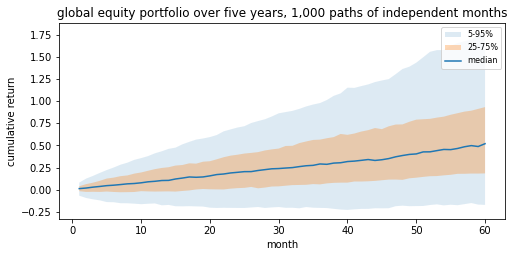

5%     -17.2
50%     52.0
95%    178.3
Name: cumulative return at 60 months, dtype: float64

In [13]:
P = fm.simulate_paths(1000, 60, seed=2)
rp_paths = P.array @ w.values                                 # (1000, 60) portfolio returns per month
cum = np.cumprod(1 + rp_paths, axis=1) - 1
q = np.quantile(cum, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.fill_between(range(1, 61), q[0], q[4], alpha=0.15, label="5-95%"); ax.fill_between(range(1, 61), q[1], q[3], alpha=0.3, label="25-75%"); ax.plot(range(1, 61), q[2], label="median")
ax.set_xlabel("month"); ax.set_ylabel("cumulative return"); ax.set_title("global equity portfolio over five years, 1,000 paths of independent months"); ax.legend(fontsize=8); plt.show()
pd.Series(np.quantile(cum[:, -1], [0.05, 0.5, 0.95]), index=["5%", "50%", "95%"], name="cumulative return at 60 months").mul(100).round(1)

### Save and reload

The fitted generator is a small JSON file: the targets and the coefficients.
Reloaded, it simulates the same data without the history. The acceptance
check of Step 3 needs a large draw; for a handful of observations it is
switched off.

In [14]:
fm.save("moments_market.json")
FleishmanMarket.load("moments_market.json").simulate(5, seed=3, accept=False).round(4)   # accept=False: a draw of 5 cannot meet a correlation tolerance

,SPY,IWM,EFA,TLT,IEF,GLD
0,0.0881,0.0434,0.0896,-0.0116,-0.0045,0.0151
1,-0.0890,-0.1096,-0.1188,0.2037,0.0766,0.0118
2,0.0017,-0.0183,-0.0269,-0.0102,-0.0006,-0.0130
3,0.0480,0.0494,0.0431,0.0613,0.0322,0.0147
4,0.0057,0.0158,0.0436,-0.0069,-0.0012,0.0730


## What this generator misses

The tables above gave the exceedance correlation at three thresholds; the plot
below gives the whole profile, $\hat\rho(z)$ for $z$ from $-1$ to $+1$
standard deviations of SPY, against each other asset: the history in black,
the synthetic data in blue. For SPY against EFA and IWM the history's profile
falls from left to right, the correlation highest in SPY's worst months, and
the synthetic profile is flat at the target correlation. For SPY against TLT
and GLD both profiles are flat: the property the 60/40 misses, coinciding
sizes of moves, does not show in this plot, which conditions on the sign of
SPY's move; it showed in the co-kurtosis. Notebook 02 names the two
properties, tail dependence with and without direction, measures them, and
introduces the generator that reproduces both.

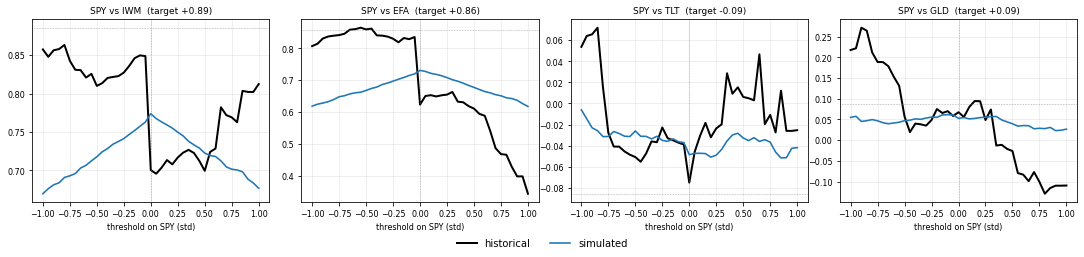

In [15]:
fig = fm.plot_exceedance(S, base="SPY", pairs=["IWM", "EFA", "TLT", "GLD"], ncols=4)
fig.set_size_inches(15, 3.6); plt.show()

## What was learned, and what comes next

Targets, fit, check, use: the history's moments and correlations as targets, a
generator that matches them exactly, a check that says so, and the uses: a
portfolio's tail on as much data as needed, and two views, on correlations
and on a volatility, each moving the portfolio by exactly what the arithmetic
of the targets implies. The generator reproduces every number it was given and
misses what it was not given, in two forms: equity markets that move together
more in bad months than in good ones, and equity and bonds whose large moves
coincide in either direction. Both cost a portfolio its skewness and kurtosis,
and so its tail.

**Notebook 02** defines tail dependence for a pair, with and without a
direction, measures both in the history, and introduces the second generator,
which selects for each pair a copula whose tails match the history's and
reproduces the exceedance profile while matching the same moments and
correlations. On this same equity portfolio it recovers the history's skewness, kurtosis and
expected shortfall.